<a href="https://colab.research.google.com/github/datadoraemon98/ML_ASSIGNMENT/blob/main/ps1_1_b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
df = pd.read_csv('/content/ds1_train.csv')
print(df.head())

        x_1         x_2    y
0  2.911809   60.359613  0.0
1  3.774746  344.149284  0.0
2  2.615488  178.222087  0.0
3  2.013694   15.259472  0.0
4  2.757625   66.194174  0.0


In [2]:


# Define features (X) and target (y)
X = df[['x_1', 'x_2']]
y = df['y']


In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Load the validation dataset
df_valid = pd.read_csv('/content/ds1_valid.csv')

# Prepare features (X_valid) and target (y_valid) for the validation set
X_valid = df_valid[['x_1', 'x_2']]
y_valid = df_valid['y']

# Make predictions on the validation set
y_pred = model.predict(X_valid)

# Evaluate the model
print("Accuracy:", accuracy_score(y_valid, y_pred))
print("\nClassification Report:\n", classification_report(y_valid, y_pred))

Accuracy: 0.9

Classification Report:
               precision    recall  f1-score   support

         0.0       0.95      0.84      0.89        50
         1.0       0.86      0.96      0.91        50

    accuracy                           0.90       100
   macro avg       0.91      0.90      0.90       100
weighted avg       0.91      0.90      0.90       100



In [ ]:
import numpy as np

# Scale features
X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)

# Add intercept
X_scratch = np.c_[np.ones(X_scaled.shape[0]), X_scaled]


# Sigmoid
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))


# Cost function
def compute_cost(X, y, theta):
    m = len(y)

    h = sigmoid(X @ theta)

    # Prevent log(0)
    h = np.clip(h, 1e-15, 1 - 1e-15)

    cost = (-1/m) * np.sum(
        y * np.log(h) +
        (1-y) * np.log(1-h)
    )

    return cost


# Gradient Descent
def gradient_descent(X, y, theta, learning_rate, num_iterations):

    m = len(y)
    costs = []

    for _ in range(num_iterations):

        # Predictions
        h = sigmoid(X @ theta)

        # Gradient
        gradient = (1/m) * X.T @ (h-y)

        # Update parameters
        theta = theta - learning_rate * gradient

        # Cost
        costs.append(compute_cost(X, y, theta))

    return theta, costs


# Initialize parameters
theta_scratch = np.zeros(X_scratch.shape[1])

learning_rate = 0.1
num_iterations = 10000


# Train
theta_trained, costs = gradient_descent(
    X_scratch,
    y,
    theta_scratch,
    learning_rate,
    num_iterations
)


print("Optimized parameters:", theta_trained)
print("Final Cost:", costs[-1])

Optimized parameters: [-0.3255614   2.76707749 -3.40528988]
Final Cost: 0.3255719112353222


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Load the validation dataset
df_valid_scratch = pd.read_csv('/content/ds1_valid.csv')

# Prepare features (X_valid) and target (y_valid) for the validation set
X_valid_scratch = df_valid_scratch[['x_1', 'x_2']]
y_valid_scratch = df_valid_scratch['y']

# Scale validation features using the mean and std from the TRAINING data (X)
X_valid_scaled_scratch = (X_valid_scratch - X.mean(axis=0)) / X.std(axis=0)

# Add intercept to scaled validation features
X_valid_scratch_processed = np.c_[np.ones(X_valid_scaled_scratch.shape[0]), X_valid_scaled_scratch]

# Prediction function for the scratch model
def predict_scratch(X_processed, theta):
    probabilities = sigmoid(X_processed @ theta)
    return (probabilities >= 0.5).astype(int)

# Make predictions on the validation set using the trained parameters
y_pred_scratch = predict_scratch(X_valid_scratch_processed, theta_trained)

# Evaluate the model
print("Accuracy (Scratch Model):", accuracy_score(y_valid_scratch, y_pred_scratch))
print("\nClassification Report (Scratch Model):\n", classification_report(y_valid_scratch, y_pred_scratch))

Accuracy (Scratch Model): 0.9

Classification Report (Scratch Model):
               precision    recall  f1-score   support

         0.0       0.95      0.84      0.89        50
         1.0       0.86      0.96      0.91        50

    accuracy                           0.90       100
   macro avg       0.91      0.90      0.90       100
weighted avg       0.91      0.90      0.90       100



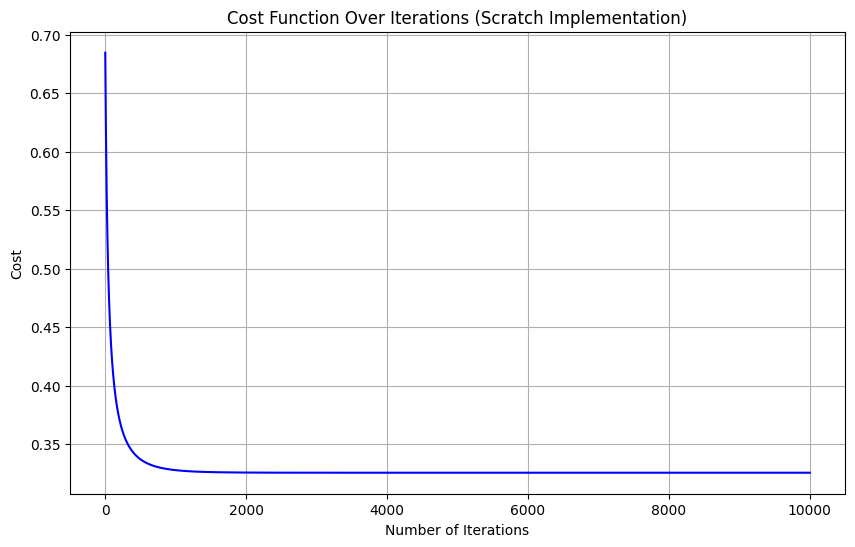

In [ ]:
import matplotlib.pyplot as plt

# Plot the cost over iterations
plt.figure(figsize=(10, 6))
plt.plot(range(len(costs)), costs, color='blue')
plt.xlabel('Number of Iterations')
plt.ylabel('Cost')
plt.title('Cost Function Over Iterations (Scratch Implementation)')
plt.grid(True)
plt.show()

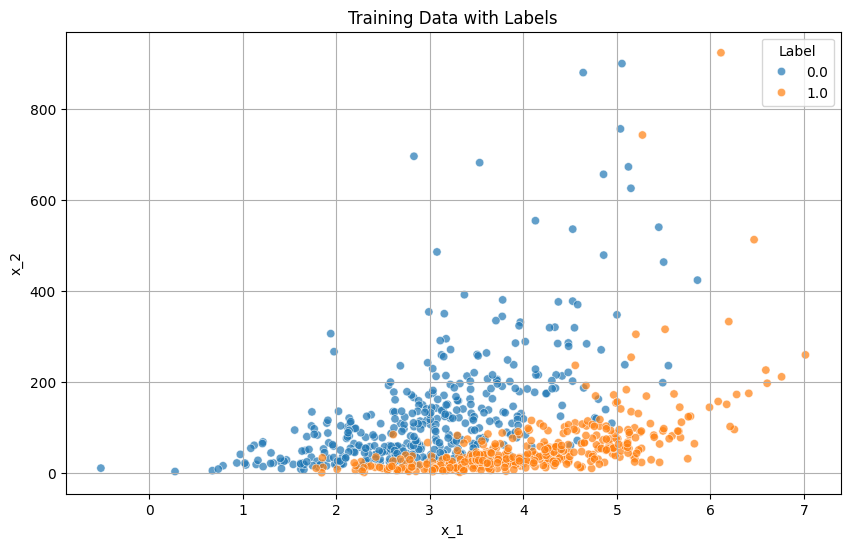

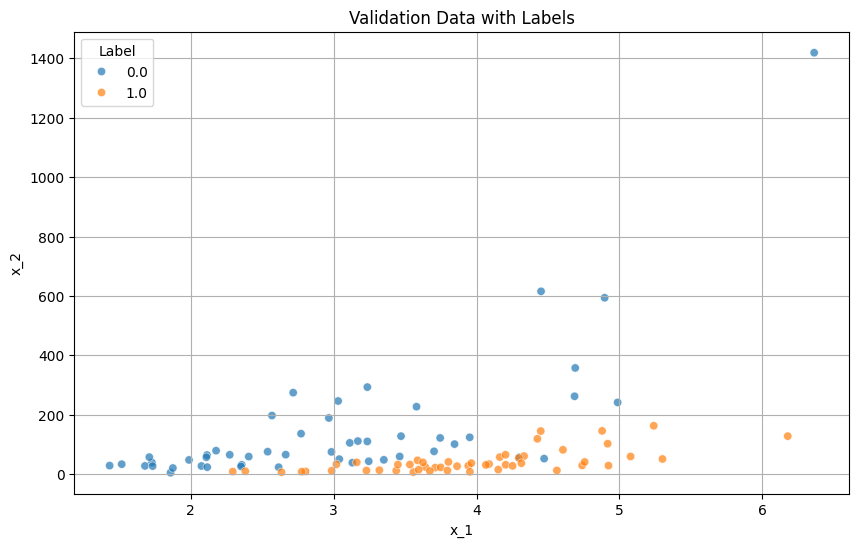

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot for Training Data
plt.figure(figsize=(10, 6))
sns.scatterplot(x='x_1', y='x_2', hue='y', data=df, alpha=0.7)
plt.title('Training Data with Labels')
plt.xlabel('x_1')
plt.ylabel('x_2')
plt.legend(title='Label')
plt.grid(True)
plt.show()

# Plot for Validation Data
plt.figure(figsize=(10, 6))
sns.scatterplot(x='x_1', y='x_2', hue='y', data=df_valid_scratch, alpha=0.7)
plt.title('Validation Data with Labels')
plt.xlabel('x_1')
plt.ylabel('x_2')
plt.legend(title='Label')
plt.grid(True)
plt.show()